# Проект. Исследование стартапов

- Автор: Агансонов Руслан
- Дата: 12.01

## Введение

### Цель проекта

**Цель:** Провести исследовательский анализ исторических данных о стартапах и оценить перспективы выхода на рынок с покупкой и развитием компаний. 

### Задачи проекта

- Провести предобработку данных, убрать дубликаты и пропуски, проверить корректность числовых и временных значений.
- Выделить группы компаний по срокам финансирования и сравнить их по количеству и объёму инвестиций.
- Классифицировать сегменты рынка на массовые, средние и нишевые и учесть это в дальнейшем анализе.
- Определить типичные и аномальные значения объёмов финансирования, исключить выбросы и ограничить период исследования.
- Сравнить популярность и объёмы разных типов финансирования.
- Проанализировать динамику раундов и объёмов инвестиций по годам, а также изменения в массовых сегментах рынка.
- Рассчитать долю возврата средств для разных типов финансирования и оценить её устойчивость.
- Подвести итоговые выводы и дать рекомендации, куда и каким образом было бы целесообразно инвестировать, если бы на дворе был 2015 год.

### Содержимое проекта

1. Знакомство с данными
2. Инжиниринг признаков
3. Работа с выбросами и анализ
4. Анализ динамики
5. Итоговый вывод и рекомендации

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

Файлы находятся в папке `datasets`, если вы выполняете работу на платформе. В случае, если вы делаете работу локально, доступ к файлам в папке можно получить по адресу `https://code.s3.yandex.net/datasets/` + имя файла.

### 1.1. Вывод общей информации

Загрузим необходимые для работы библиотеки.


In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Выгружаем данные в переменные df_investments и df_returns, а также создадим копию df
df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)
df_investments = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)
df_returns = pd.read_csv('/datasets/cb_returns.csv')

Выведем информацию, которая необходима для принятия решений о предобработке. Познакомимся с данными датасетов `rest_info.csv` и `rest_price.csv` — выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [3]:
# Выводим первые строки датафрейма на экран
df_investments.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# Выводим информацию о датафрейме
df_investments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [5]:
# Выводим первые строки датафрейма на экран
df_returns.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [6]:
# Выводим информацию о датафрейме
df_returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


Датасет `cb_investments.csv` содержит 40 столбцов и 54294 строк, в которых представлена информация о информацию о компаниях и состоявшемся финансировании.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов `market` и `funding_total_usd` нужно очистить от лишних пробелов. Остальные столбцы приведены к нужному стилю.
- Представленные данные содержат числовые и строковые значения, которые хранятся в типах данных `float64` или `object`.  Значения в столбце `category_list` представлены в виде строк, однако характеризирует какую-либо категорию — тип данных для таких столбцов можно оптимизировать.
- Пропуски содержатся во всех столбцах. Также следует проверить значения: в них могут встречаться индикаторы, которые будут говорить об отсутствии данных.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

Датасет `cb_returns.csv` содержит 14 столбцов и 15 строк, в которых представлена информация о об объёмах возвратов по годам и типам финансирования в миллионах долларов. По аналогии с предыдущим датасетом можно отметить, что:

- Названия столбцов изначально приведены к нужному формату.
- Типы данных соответствуют содержимому. Тип данных для столбца `year` можно оптимизировать до меньшего разряда.
- Пропусков на первый взгляд нет, однако следует проверить в столбцах значения-индикаторы, которые могут говорить об отсутствии данных.
- Значения в столбцах соответствуют описанию.

Первичное знакомство показывает, что данные среднего качества — в них достаточно пропущенных значений, а сами данные соответствуют описанию и выглядят корректными. Настало время следующего этапа — предобработки данных.

### 1.2. Предобработка данных

Проверим названия столбцов в датасетах: все ли они точно отражают содержимое данных и оформлены в удобном для работы стиле. При необходимости приведем их к единому аккуратному стилю.

In [7]:
#Выведем названия всех столбцов для датафрейма df_investments
df_investments.columns

Index(['name', 'homepage_url', 'category_list', ' market ',
       ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

Заметим, что в некоторых названиях столбцов присутствуют лишние пробелы. Очистим их с помощью метода strip().

In [8]:
#Переименуем названия столбцов в нужном стиле
df_investments.columns = df_investments.columns.str.strip()
df_investments.columns

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

Рассмотрим теперь названия столбцов в датафрейме df_returns:

In [9]:
#Выведем названия столбцов для датафрейма df_returns
df_returns.columns

Index(['year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
       'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding'],
      dtype='object')

Столбцы соответствуют стилю.

Уберем в столбце `funding_total_usd` выделение разрядов и приведем его к числовому типу.

In [10]:
#Приведем столбец funding_total_usd к нужному числовому типу
df_investments['funding_total_usd'] = pd.to_numeric(df_investments['funding_total_usd'] \
                                                    .str.replace(',', ''), errors='coerce')

Обработаем типы данных в столбцах, которые хранят значения даты и времени, если это необходимо.

In [11]:
#Изменим тип данных на datetime в столбцах, которые указывают на дату
for column in ['founded_at', 'founded_month', 'founded_quarter', 'founded_year', \
               'first_funding_at', 'mid_funding_at', 'last_funding_at']:
    df_investments[column] = pd.to_datetime(df_investments[column], errors='coerce')

In [12]:
#Понизим разряд типа данных для столбца year в датафрейме df_returns
df_returns['year'] = pd.to_numeric(df_returns['year'], downcast='integer')

В датасете `cb_returns` сделаем столбец `year` индексом всего датасета.

In [13]:
#Сделаем столбец year индексом всего датасета df_returns
df_returns.set_index('year', inplace=True)

Обработаем текстовые данные, если это необходимо. Пропуски в текстовых столбцах заполним заглушками там, где это понадобится.

In [14]:
#Рассмотрим количество категорий в столбце category_list
df_investments['category_list'].nunique()

16675

16675 категорий в столбце не являются ограниченным диапазоном для того чтобы менять тип данных на category, как планировалось ранее. Теперь, проверим данные на пропуски:

In [15]:
#Удалим строки со всеми пропусками в столбцах
df_investments.dropna(how='all', inplace=True)

In [16]:
#Проверим есть ли пустые значения в столбце с названием компаний
df_investments['name'].isna().sum()

1

Заполним пропуски в некоторых столбцах "заглушками" для удобства анализа.

In [17]:
#Заполним пропуске в столбце homepage_url значением 'Нет сайта'
df_investments['homepage_url'] = df_investments['homepage_url'].fillna('Нет сайта')

In [18]:
#Изменим тип данных status на тип данных category
df_investments['status'] = df_investments['status'].astype('category')

In [19]:
#Заполним пустые значения в столбцах, связанных с местоположением компании, значением 'Местоположение неизвестно'
for column in ['country_code', 'state_code', 'region', 'city']:
    df_investments[column] =  df_investments[column].fillna('Местоположение неизвестно')

In [20]:
#Заполним пустые строки в столбце с названием компании на 'Неизвестно'
df_investments['name'] = df_investments['name'].fillna('Неизвестно')

In [21]:
#Заполним пустые строки в столбце с сегментом рынка на 'Неизвестно'
df_investments['market'] = df_investments['market'].fillna('Неизвестно')

Обработаем полные дубликаты в данных и пропуски в `funding_total_usd`, избавимся от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании.

In [22]:
#Уберем из датафрейма полные дубликаты строк
df_investments.drop_duplicates(inplace=True)

In [23]:
#Проверим количество дубликатов в готовом датасете
df_investments.duplicated().sum()

0

In [24]:
#Удаляем строки, где в столбце 'funding_total_usd' пусто
df_investments.dropna(subset=['funding_total_usd'], inplace=True)

In [25]:
#Не совсем понятно, нужно ли удалять пустые значения во всех столбцах связанных с финансированием (к примеру столбец participants)
df_investments.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 40907 entries, 0 to 49437
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  40907 non-null  object        
 1   homepage_url          40907 non-null  object        
 2   category_list         38404 non-null  object        
 3   market                40907 non-null  object        
 4   funding_total_usd     40907 non-null  float64       
 5   status                39802 non-null  category      
 6   country_code          40907 non-null  object        
 7   state_code            40907 non-null  object        
 8   region                40907 non-null  object        
 9   city                  40907 non-null  object        
 10  funding_rounds        40907 non-null  float64       
 11  participants          27331 non-null  float64       
 12  founded_at            32200 non-null  datetime64[ns]
 13  founded_month   

Заполним пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмем приблизительно середину интервала между этими двумя датами.


In [27]:
#Заполним пропуски столбца mid_funding_at на основании значений в столбцах first_funding_at и last_funding_at
df_investments['mid_funding_at'].fillna(
    df_investments['first_funding_at'] + (df_investments['last_funding_at'] - df_investments['first_funding_at']) / 2, 
    inplace=True)

In [29]:
#Отбросим строки с пустым значением в столбце first_funding_at
df_investments.dropna(subset=['first_funding_at'], inplace=True)

Оценим полноту данных и сделаем предварительный вывод о том, достаточно ли данных для решения задач проекта.

In [30]:
#Выведем информацию о датафрейме и оценим полноту данных
df_investments.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 40905 entries, 0 to 49437
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  40905 non-null  object        
 1   homepage_url          40905 non-null  object        
 2   category_list         38402 non-null  object        
 3   market                40905 non-null  object        
 4   funding_total_usd     40905 non-null  float64       
 5   status                39800 non-null  category      
 6   country_code          40905 non-null  object        
 7   state_code            40905 non-null  object        
 8   region                40905 non-null  object        
 9   city                  40905 non-null  object        
 10  funding_rounds        40905 non-null  float64       
 11  participants          27330 non-null  float64       
 12  founded_at            32198 non-null  datetime64[ns]
 13  founded_month   

In [31]:
#Рассчитаем долю оставшихся данных от исходного датасета
df_investments.shape[0]/df.shape[0]

0.753398165543154

In [32]:
#Рассмотрим долю пустых значений в итоговом датафрейме
df_investments.isna().sum()/df_investments.shape[0]

name                    0.000000
homepage_url            0.000000
category_list           0.061191
market                  0.000000
funding_total_usd       0.000000
status                  0.027014
country_code            0.000000
state_code              0.000000
region                  0.000000
city                    0.000000
funding_rounds          0.000000
participants            0.331867
founded_at              0.212859
founded_month           0.214448
founded_quarter         0.214448
founded_year            0.212835
first_funding_at        0.000000
mid_funding_at          0.000000
last_funding_at         0.000000
seed                    0.000000
venture                 0.000000
equity_crowdfunding     0.000000
undisclosed             0.000000
convertible_note        0.000000
debt_financing          0.000000
angel                   0.000000
grant                   0.000000
private_equity          0.000000
post_ipo_equity         0.000000
post_ipo_debt           0.000000
secondary_

In [33]:
#Рассмотрим долю пропусков для датафрейма df_returns
df_returns.isna().sum()/df_investments.shape[0]

seed                    0.0
venture                 0.0
equity_crowdfunding     0.0
undisclosed             0.0
convertible_note        0.0
debt_financing          0.0
angel                   0.0
grant                   0.0
private_equity          0.0
post_ipo_equity         0.0
post_ipo_debt           0.0
secondary_market        0.0
product_crowdfunding    0.0
dtype: float64

В ходе предобработки данных была проведена очистка названий столбцов, изменение типов данных (включая перевод дат в формат datetime и очистку числовых значений от лишних символов), а также обработка пропусков.

После удаления полных дубликатов и строк с критическими пропусками в столбцах funding_total_usd и first_funding_at было сохранено 75,34% от исходного датасета. Таким образом, доля удаленных данных составила около 24,66%.

Несмотря на удаление почти четверти данных, оставшегося объема (40 905 записей) более чем достаточно для решения задач проекта и проведения анализа.

## Шаг 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования

Разделим все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируем соотношение этих групп, создав два графика:

* По количеству компаний: Покажите, какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: Отобразите, какую долю от общего объёма привлечённых средств получила каждая группа.


In [34]:
#Создадим функцию которая разделит компании на три группы в зависимости от раундов финансирования
def define_category(row):
    first = row['first_funding_at']
    last = row['last_funding_at']    
    if last == first:
        return 'Единичное финансирование'
    
    diff = (last - first).days
    
    if diff > 365:
        return 'Срок финансирования более года'
    return 'Срок финансирования до года'

#Применим функцию к датафрейму
df_investments['funding_category'] = df_investments.apply(define_category, axis=1)

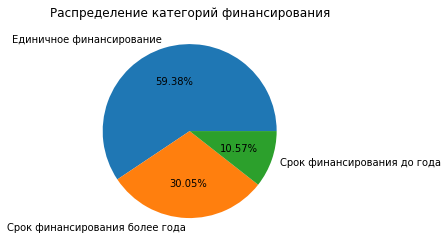

In [35]:
#Сгруппируем данные по категории финансирования и выведем круговую диаграмму распределения:
ax = df_investments.groupby('funding_category')['name'].count().plot(kind='pie', autopct='%1.2f%%')
ax.set_title('Распределение категорий финансирования')
ax.set_ylabel('')
plt.show()

Из визуализации распределения категорий финансирования видно, что преобладает единичное финансирование (59.4%), за ним следует финансирование сроком до года (30%), а наименьшую долю составляет финансирование сроком более года (10.6%).



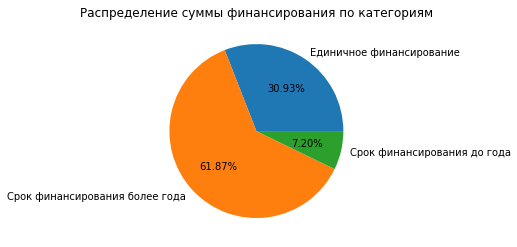

In [36]:
#Сгруппируем данные по категории финансирования и выведем круговую диаграмму распределения суммы финансирования:
ax = df_investments.groupby('funding_category')['funding_total_usd'].sum().plot(kind='pie', autopct='%1.2f%%')
ax.set_title('Распределение суммы финансирования по категориям')
ax.set_ylabel('')
plt.show()

При рассмотрении распределения же суммы финансирования по категориям наблюдается другая картина - наибольшую долю занимает финансирование сроком более года (61.9%), за ним следует единичное финансирование (30.9%), а наименьшая доля приходится на финансирование сроком до года (7.2%).

### 2.2 Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце `market`. Рассчитаем, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесем к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесем к средним, а сегменты до 35 компаний отнесем к нишевым. Рассчитаем, сколько сегментов попадает в каждую из категорий.

Также, построим график распределения количества компаний в сегментах и отобразим на нём разделение на нишевые и средние сегменты.

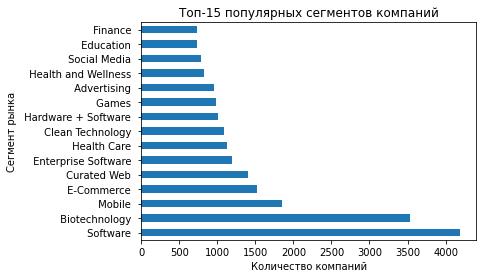

In [37]:
#Построим распределение сегментов рынка топ-15 компаний
ax = df_investments[df_investments['market'] != 'Неизвестно'].groupby('market')['name'].count() \
        .sort_values(ascending=False).head(15).plot(kind='barh')
ax.set_title('Топ-15 популярных сегментов компаний')
ax.set_xlabel('Количество компаний')
ax.set_ylabel('Сегмент рынка')
plt.show()

На представленой диаграмме топ-15 самых популярных сегментов рынка по количеству компаний, лидирует сегмент Software с показателем около 4100 компаний, значительно опережая Biotechnology (около 3500) и Mobile (около 1850).

In [38]:
#Создадим функцию для категоризации сегмента рынка по количеству компаний в нем
def define_category(counter):
    if counter > 120:
        return 'Массовый'    
    if counter < 35:
        return 'Нишевый'
    return 'Средний'

#Считаем частоту каждого сегмента рынка
market_counts = df_investments['market'].value_counts()
df_investments['market_category'] = df_investments['market'].map(market_counts).apply(define_category)

In [39]:
#Перебор категорий в цикле
for category in ['Массовый', 'Средний', 'Нишевый']:
    count = df_investments[df_investments['market_category'] == category]['market'].nunique()
    print(f"{category}: {count}")

Массовый: 54
Средний: 81
Нишевый: 714


Заметим, что наиболее уникальным набором категорий обладают нишевая категория сегмента рынка - 714 различных сегментов рынка. Наиболее же узконаправленным можно считать массовый сегмент рынка (54 различных сегмента).

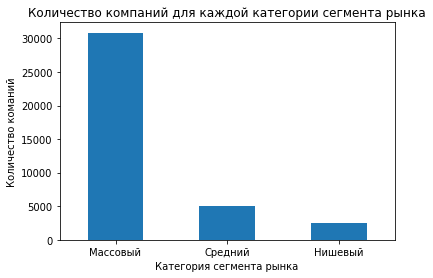

In [40]:
#Создадим столбчатую диаграмму распеределения количества компаний в каждой категории сегмента рынка
ax = df_investments[df_investments['market'] != 'Неизвестно'].groupby('market_category')['market'].count() \
        .sort_values(ascending=False).plot(kind='bar', rot=0)
ax.set_title('Количество компаний для каждой категории сегмента рынка')
ax.set_ylabel('Количество команий')
ax.set_xlabel('Категория сегмента рынка')
plt.show()

При рассмотрении количество компаний для каждой категории сегмента рынка наблюдается обратная картина - около 30000 компаний являются массовым сегментом, когда нишевых компаний около 2500.

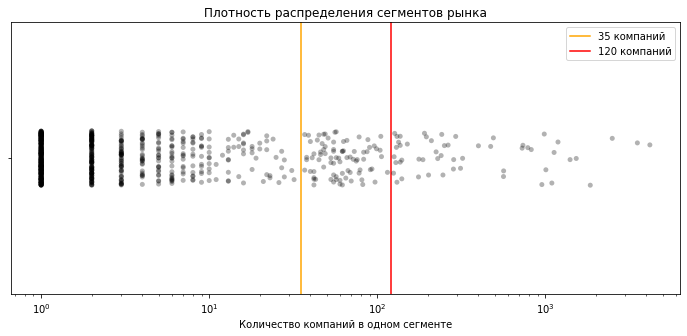

In [41]:
#Выведем плотность распределения сегментов рынка по количеству компаний
plt.figure(figsize=(12, 5))
sns.stripplot(x=market_counts, color="black", alpha=0.3, jitter=True)
#Выведем две линии ограничивающие сегменты на 35 и 120 компаний
plt.axvline(35, color='orange', label='35 компаний')
plt.axvline(120, color='red', label='120 компаний')
#Зададим ось X в логарифмическом масштабе
plt.xscale('log')
plt.title('Плотность распределения сегментов рынка')
plt.xlabel('Количество компаний в одном сегменте')
plt.legend()
plt.show()

График демонстрирует распределение плотности вероятности количества компаний в сегментах рынка, которое имеет ярко выраженную правостороннюю асимметрию: подавляющее большинство сегментов содержат менее 35 компаний, в то время как лишь небольшое число сегментов насчитывает более 120 компаний. Дополнительно построим гистограмму распределения.

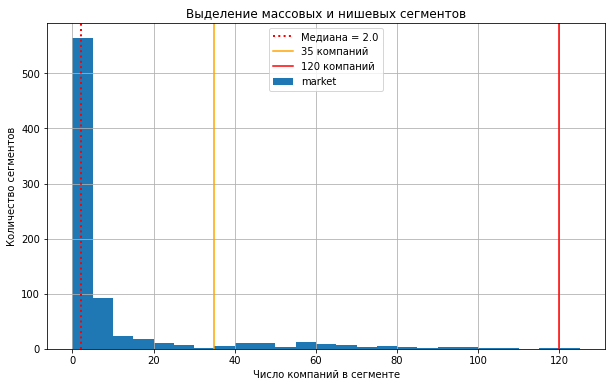

In [42]:
#Дополнительно выведем гистограмму распределения
ax = market_counts.plot(kind='hist', bins=25, range=(0, 125), figsize=(10, 6))
# Добавляем линию медианы
plt.axvline(x=market_counts.median(), color='red', linestyle=':', linewidth=2, label=f'Медиана = {market_counts.median()}')
#Оформляем границы диапазона
plt.axvline(35, color='orange', label='35 компаний')
plt.axvline(120, color='red', label='120 компаний')
#Сделаем оформление графика
ax.set_title('Выделение массовых и нишевых сегментов')
ax.set_xlabel('Число компаний в сегменте')
ax.set_ylabel('Количество сегментов')
plt.grid(True)
plt.legend()
plt.show()

Гистограмма детализирует эту картину, наглядно показывая, что половина всех рыночных сегментов включает в себя не более двух компаний (Медиана = 2), что свидетельствует о подавляющем преобладании нишевых сегментов.

Оставим в столбце `market` только массовые сегменты. Для остальных сегментов заменим значения на заглушки — `niche` для нишевых и `mid` для средних.

In [43]:
#Оставим в столбце market только массовые сегменты
df_investments.loc[df_investments['market_category'] == 'Нишевый', 'market'] = 'niche'
df_investments.loc[df_investments['market_category'] == 'Средний', 'market'] = 'mid'

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

По предобработанному столбцу `funding_total_usd` графическим образом оценим, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Укажим интервал, в котором лежат типичные значения.

In [44]:
#Рассмотрим тенденцию размера общего финансирования для всех компаний
df_investments['funding_total_usd'].describe()

count    4.090500e+04
mean     1.591247e+07
std      1.686829e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64

Среднее арифметическое сильно отличается от медианы в большую сторону, это определяет то, что в данных содержится большое количество выбросов.

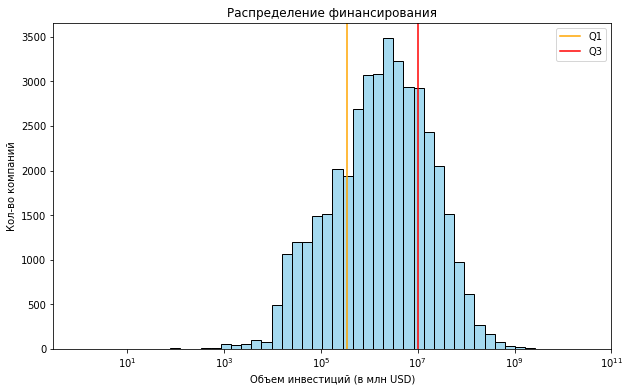

In [45]:
#Выведем гистограмму распределения финансирования в логарифмическом масштабе и определим типичное значение
plt.figure(figsize=(10, 6))
sns.histplot(df_investments['funding_total_usd'], bins=50, log_scale=True, color='skyblue')
plt.axvline(df_investments['funding_total_usd'].quantile(0.25), color='orange', label='Q1')
plt.axvline(df_investments['funding_total_usd'].quantile(0.75), color='red', label='Q3')
plt.title('Распределение финансирования')
plt.xlabel('Объем инвестиций (в млн USD)')
plt.ylabel('Кол-во компаний')
plt.legend()
plt.show()

На гистограмме представлено логарифмически-нормальное распределение количества компаний по объёму полученных инвестиций, демонстрирующее резкое снижение числа компаний с ростом финансирования, при этом основная масса компаний сконцентрирована в диапазоне от десятков тысяч до нескольких миллионов долларов, а максимальные инвестиции на уровне миллиардов получают лишь единичные компании.

Определим компании с аномальным объёмом общего финансирования - используя метод IQR отдельно по каждому сегменту.

Также, определим сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведем топ таких сегментов.

In [46]:
#Посчитаем Q1 и Q3 для каждого сегмента рынка
df_investments['q1'] = df_investments.groupby('market')['funding_total_usd'].transform('quantile', 0.25)
df_investments['q3'] = df_investments.groupby('market')['funding_total_usd'].transform('quantile', 0.75)
#Рассчитаем межквартильный размах и значение отсекающее выбросы
df_investments['iqr'] = df_investments['q3'] - df_investments['q1']
df_investments['upper_bound'] = df_investments['q3'] + 1.5 * df_investments['iqr']
df_investments['lower_bound'] = df_investments['q1'] - 1.5 * df_investments['iqr']
#Помечаем аномалии с помощью столбца is_outlier
df_investments['is_outlier'] = (df_investments['funding_total_usd'] > df_investments['upper_bound']) | \
                                (df_investments['funding_total_usd'] < df_investments['lower_bound'])
#Найдем аномальные компании
anomalous_companies = df_investments[
    (df_investments['is_outlier']) & (df_investments['market'] != 'Неизвестно')
]

#Считаем долю аномалий по сегментам
anomaly_stats = df_investments[df_investments['market'] != 'Неизвестно'].groupby('market').agg(
    total_companies=('name', 'count'),
    outlier_count=('is_outlier', 'sum')
)
anomaly_stats['outlier_share'] = anomaly_stats['outlier_count'] / anomaly_stats['total_companies']

#Выводим Топ-10 аномальных сегментов
anomaly_stats.sort_values(by='outlier_share', ascending=False).head(10)

,total_companies,outlier_count,outlier_share
market,,,
Real Estate,251,45,0.179283
Technology,229,37,0.161572
Search,242,39,0.161157
Software,137,22,0.160584
Entertainment,137,22,0.160584
Cloud Computing,131,21,0.160305
Big Data,140,22,0.157143
SaaS,224,35,0.156250
E-Commerce,129,20,0.155039


In [47]:
#Выведем медиану для доли выбросов
anomaly_stats.sort_values(by='outlier_share', ascending=False).head(10).median()

total_companies    182.000000
outlier_count       28.500000
outlier_share        0.160445
dtype: float64

Лидером по доле компаний с аномально высоким объемом финансирования стал сегмент Real Estate (почти 18%), за которым следуют Technology и Search. В целом, в топ-10 вошли преимущественно высокотехнологичные отрасли, где доля таких «выбросов» варьируется в узком диапазоне от 15% до 18%.

Типичным размером общего финансирования для одной компании является медианное значение, составляющее 2 млн долларов. Основная масса значений лежит в интервале от 350 тысяч до 10 млн (между Q1 и Q3), а суммы, превышающие расчетную верхнюю границу размаха в 24,5 млн (Q3 + 1.5*IQR), считаются выбросами.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверим по датасету, можно ли считать, что нам предоставили полные данные за 2014 год. Затем исключим из датасета компании, которые мы ранее посчитали получившими аномальное финансирование.

Затем, на основе столбцов `mid_funding_at` и `funding_rounds` оставим в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [48]:
#Рассмотрим данные с первым финансированием в 2014 году 
df_investments[df_investments['first_funding_at'].dt.year == 2014]['first_funding_at'].nunique()

330

Количество уникальных дат с первым финансированием примерно равно количеству дней в году, значит данные должны покрывать весь 2014 год.

In [49]:
#Выведем количество уникальных дат основания компаний в 2014 году
df_investments[df_investments['founded_at'].dt.year == 2014]['founded_at'].nunique()

204

Количество уникальных дат с первым финансированием примерно равно половине количества дней в году, значит данные могут не покрывать весь 2014 год. Проверим разницу между максимальной и минимальной датой:

In [50]:
#Найдем размах распределения дат основания компаний
df_investments[df_investments['founded_at'].dt.year == 2014]['founded_at'].max() - \
    df_investments[df_investments['founded_at'].dt.year == 2014]['founded_at'].min()

Timedelta('346 days 00:00:00')

In [51]:
#Найдем среднюю дату основания компании
df_investments[df_investments['founded_at'].dt.year == 2014]['founded_at'].mean()

Timestamp('2014-03-13 18:45:02.660098560')

Хотя временной охват составляет почти весь год (346 дней), средняя дата смещена на середину марта, что указывает на концентрацию данных в начале 2014 года. Такая аномалия подтверждает неполноту выборки: данные за второе полугодие практически отсутствуют. Однако, так как в датасете есть данные о финансировании за последний день года и о компаниях, основанных в последний месяц года, считаем, что данные за 2014 год полные.

In [52]:
#Отбросим раннее полученные аномальные компании из датасета
df_investments = df_investments[df_investments['is_outlier'] == False]

In [53]:
#Найдем для каждой компании количество раундов в год с помощью даты mid_funding_at
df_investments['funding_rounds_per_year'] = df_investments.groupby( \
    df_investments['mid_funding_at'].dt.year)['funding_rounds'].transform('sum')

In [54]:
#Исключим значения, где количество раундов за год меньше 50
df_investments = df_investments[df_investments['funding_rounds_per_year'] >= 50]

In [56]:
df_investments.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 35626 entries, 1 to 49437
Data columns (total 49 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   name                     35626 non-null  object        
 1   homepage_url             35626 non-null  object        
 2   category_list            33511 non-null  object        
 3   market                   35626 non-null  object        
 4   funding_total_usd        35626 non-null  float64       
 5   status                   34655 non-null  category      
 6   country_code             35626 non-null  object        
 7   state_code               35626 non-null  object        
 8   region                   35626 non-null  object        
 9   city                     35626 non-null  object        
 10  funding_rounds           35626 non-null  float64       
 11  participants             23269 non-null  float64       
 12  founded_at               27838 n

После отсечения данных от аномальных компаний и компаний у которых количество раундов финансирования меньше 50 получили датасет состоящий из 35626 строк.

### 3.3. Анализ типов финансирования по объёму и популярности

Построим график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Ориентируясь на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

Также построим график, который покажет популярность разных типов финансирования - какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравним графики и выделим часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот - те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

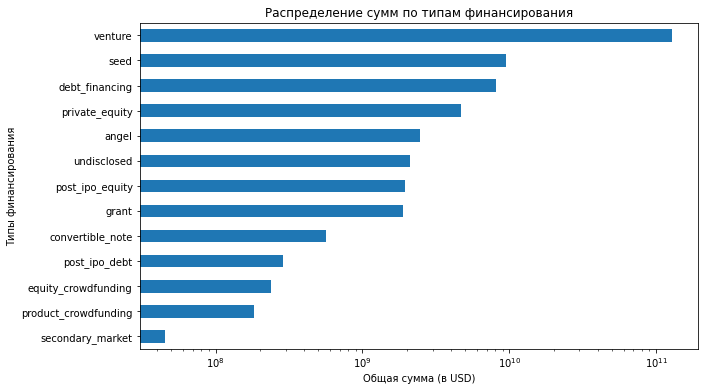

In [57]:
#Определим нужные столбцы для построения последующей визуализации
cols_to_sum = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', \
               'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']
sums = df_investments[cols_to_sum].sum()

#Строим столбчатую диаграмму
sums.sort_values().plot(kind='barh', figsize=(10, 6))
# Добавляем оформление
plt.title('Распределение сумм по типам финансирования')
plt.xlabel('Общая сумма (в USD)')
plt.ylabel('Типы финансирования')
plt.xscale('log')
plt.show()

Венчурное финансирование (venture) является абсолютным лидером по суммарному объему привлеченных средств, на несколько порядков опережая остальные категории.

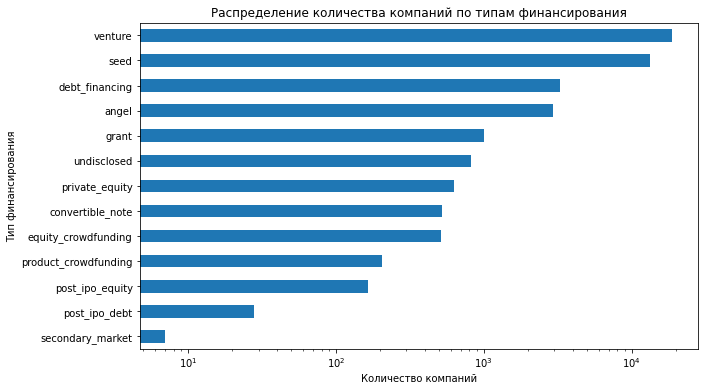

In [58]:
#Определим нужные столбцы для построения последующей визуализации
cols_to_count = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', \
               'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']
count = df_investments[df_investments[cols_to_count] != 0][cols_to_count].count()

count.sort_values().plot(kind='barh', figsize=(10, 6))
# Добавляем оформление
plt.title('Распределение количества компаний по типам финансирования')
plt.ylabel('Тип финансирования')
plt.xlabel('Количество компаний')
plt.xscale('log')
plt.show()

Венчурное (venture) и посевное (seed) финансирование являются самыми массовыми не только по объему инвестиций но и по количеству компаний, охватывая на порядки больше компаний, чем любые другие виды инвестиций.

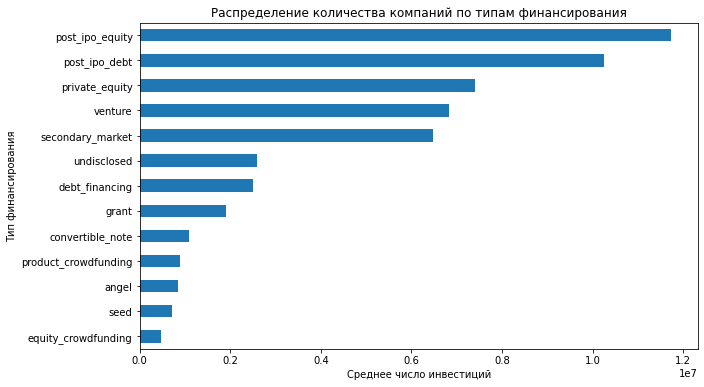

In [59]:
#Определим нужные столбцы для построения последующей визуализации
cols_to_avg = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', \
               'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']
avg = df_investments[cols_to_sum].sum() / df_investments[df_investments[cols_to_count] != 0][cols_to_count].count()

#Строим столбчатую диаграмму
avg.sort_values().plot(kind='barh', figsize=(10, 6))
# Добавляем оформление
plt.title('Распределение количества компаний по типам финансирования')
plt.ylabel('Тип финансирования')
plt.xlabel('Среднее число инвестиций')
plt.show()

Наибольший средний чек демонстрируют инструменты, такие как post_ipo_equity и post_ipo_debt, значительно опережая венчурное финансирование по размеру единичных вложений. В то же время самые массовые категории (seed и angel) характеризуются минимальными средними суммами

Построим график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

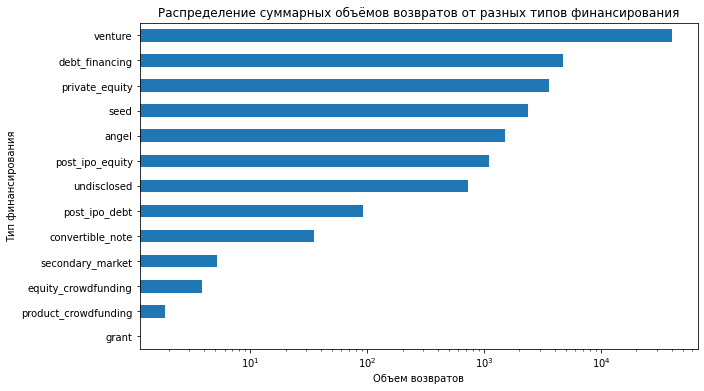

In [60]:
#Определим нужные столбцы для построения последующей визуализации
cols_to_sum = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', \
               'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']
sums = df_returns[cols_to_sum].sum()

#Строим столбчатую диаграмму
sums.sort_values().plot(kind='barh', figsize=(10, 6))

# Добавляем оформление
plt.title('Распределение суммарных объёмов возвратов от разных типов финансирования')
plt.ylabel('Тип финансирования')
plt.xlabel('Объем возвратов')
plt.xscale('log')
plt.show()

Лидером по суммарному объему возвратов является венчурное финансирование (venture), которое на порядок опережает долговое финансирование (debt_financing) и прямые инвестиции (private_equity). В то же время такие инструменты, как гранты и краудфандинг, демонстрируют минимальную или нулевую доходность.

Венчурное финансирование является абсолютным лидером рынка, доминируя как по количеству сделок и общему объему вложений, так и по суммарному возврату средств. При этом наблюдается обратная зависимость между массовостью и возвращению инвестиций: наиболее частые сделки на ранних стадиях (seed, angel) имеют минимальный средний чек, в то время как редкие инструменты поздних этапов обеспечивают максимальный объем единичных инвестиций.

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитаем для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы построим графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

На основе полученных данных нужно ответить на вопросы:
* В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?

* Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

In [61]:
#Вычислим средний объем одного раунда финансирования для каждой компании
df_investments['funding_per_round'] = df_investments['funding_total_usd'] / df_investments['funding_rounds']

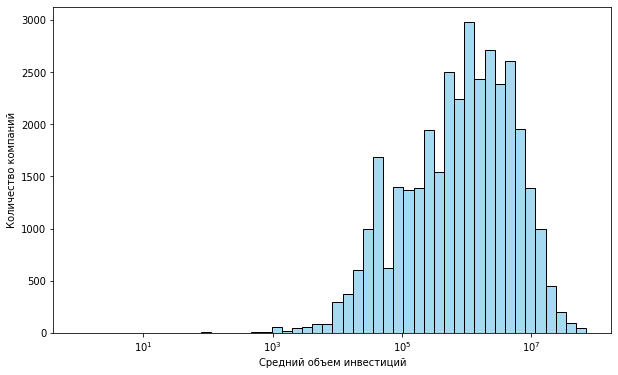

In [62]:
#Выведем гистограмму распределения среднего объема раунда финансирования
plt.figure(figsize=(10, 6))
sns.histplot(df_investments['funding_per_round'], bins=50, log_scale=True, color='skyblue')
plt.ylabel('Количество компаний')
plt.xlabel('Средний объем инвестиций')
plt.show()

Распределение среднего объема инвестиций имеет логнормальный характер с ярко выраженным пиком в районе 1 млн долларов, что является наиболее типичным размером раунда для большинства компаний. Основное количество стартапов сосредоточено в диапазоне от 100 тысяч до 10 млн долларов.

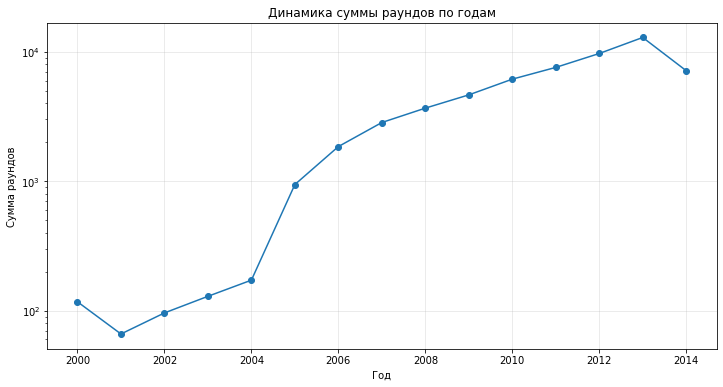

In [63]:
#Выведем количество раундов финансирования по годам
amount_of_rounds = df_investments.groupby(df_investments['mid_funding_at'].dt.year)['funding_rounds'].sum()
amount_of_rounds_sorted = amount_of_rounds.sort_index()
#Визуализиуруем данную зависимость
ax = amount_of_rounds_sorted.plot(kind='line', figsize=(12, 6), marker='o')
plt.xlabel('Год')
plt.ylabel('Сумма раундов')
plt.title('Динамика суммы раундов по годам')
plt.yscale('log')
plt.grid(True, alpha=0.3)

График демонстрирует устойчивый экспоненциальный рост числа инвестиционных раундов, начавшийся в начале 2000-х и достигший исторического максимума к 2013 году. Рассмотрим медианное значение раундов каждый из годов:

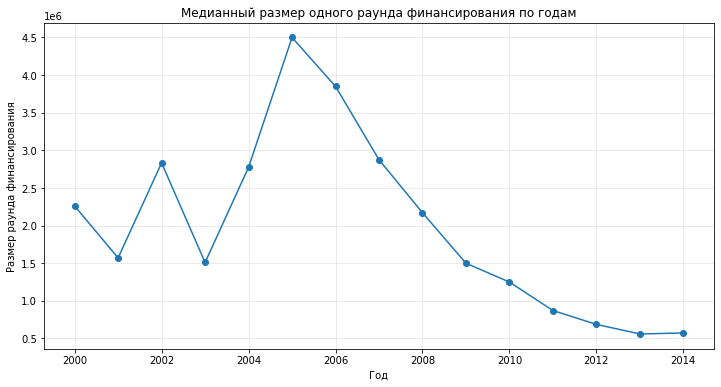

In [64]:
#Выведем медианный размер одного раунда финансирования по годам
median_of_rounds = df_investments.groupby(df_investments['mid_funding_at'].dt.year)['funding_per_round'].median()
median_of_rounds_sorted = median_of_rounds.sort_index()
#Визуализиуруем данную зависимость
ax = median_of_rounds_sorted.plot(kind='line', figsize=(12, 6), marker='o')
plt.xlabel('Год')
plt.ylabel('Размер раунда финансирования')
plt.title('Медианный размер одного раунда финансирования по годам')
plt.grid(True, alpha=0.3)

На графике видно, что после достижения резкого пика в 2005 году (около 4,5 млн), медианный размер раунда финансирования перешел к стабильному затяжному падению. К концу рассматриваемого периода (2012–2014 гг.) этот показатель опустился до минимальных значений, зафиксировавшись на уровне около 0,5 млн.

Рассмотрим 2014 год более подробно:

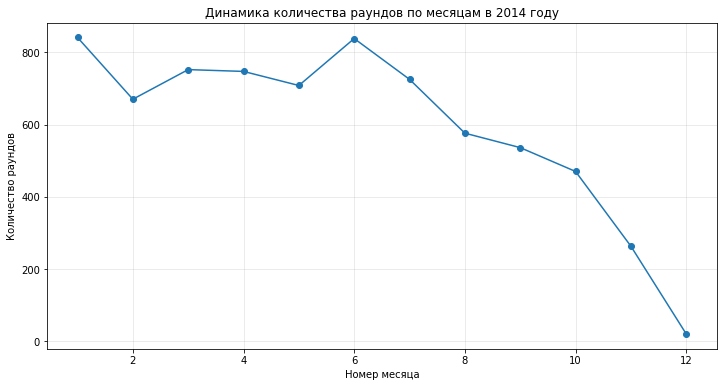

In [65]:
#Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда
amount_of_rounds_2014 = df_investments[df_investments['mid_funding_at'].dt.year == 2014] \
    .groupby(df_investments['mid_funding_at'].dt.month)['funding_rounds'].sum()
amount_of_rounds_2014_sorted = amount_of_rounds_2014.sort_index()
#Визуализиуруем данную зависимость
ax = amount_of_rounds_2014_sorted.plot(kind='line', figsize=(12, 6), marker='o')
plt.xlabel('Номер месяца')
plt.ylabel('Количество раундов')
plt.title('Динамика количества раундов по месяцам в 2014 году')
plt.grid(True, alpha=0.3)

В 2014 году прослеживается общая тенденция к снижению числа инвестиционных раундов, переходящая в резкий обрыв в последние два месяца.

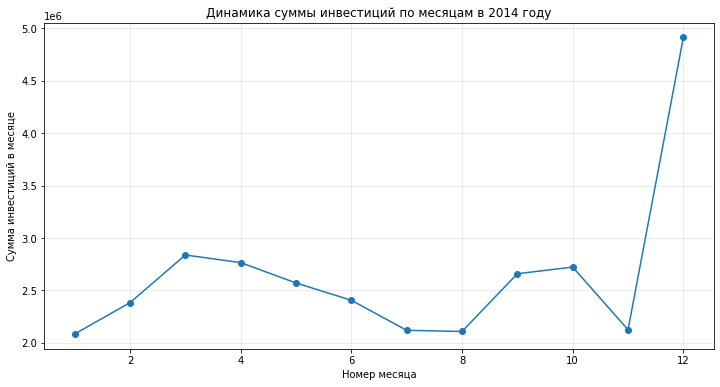

In [66]:
#Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда
amount_of_rounds = df_investments[df_investments['mid_funding_at'].dt.year == 2014].groupby(df_investments['mid_funding_at'].dt.month)['funding_total_usd'].mean()
amount_of_rounds_sorted = amount_of_rounds.sort_index()
#Визуализиуруем данную зависимость
ax = amount_of_rounds_sorted.plot(kind='line', figsize=(12, 6), marker='o')
plt.xlabel('Номер месяца')
plt.ylabel('Сумма инвестиций в месяце')
plt.title('Динамика суммы инвестиций по месяцам в 2014 году')
plt.grid(True, alpha=0.3)

Несмотря на резкое сокращение числа раундов к концу года, суммарный объем инвестиций в декабре достигает своего пика, достигая 5 млн $. Это указывает на проведение в конце периода немногих, но аномально крупных сделок, которые обеспечили основной объем финансирования за месяц.

На основании данных можно сделать вывод, что в 2005 году типичный размер средств, собранных в рамках одного раунда, был максимальным и составил около 4.5 млн долларов, а после этого года зависимость перешла к стабильному затяжному падению. При рассмотрении же 2014 года можно также заметить общую тенденция к снижению числа инвестиционных раундов. Однако, суммарный объем инвестиций в декабре аномально достигает своего пика - 5 млн $.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составим сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберем из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразим, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у вас достаточно данных. Рассматривая только массовые сегменты, а средние и нишевые исключим.

На основе графика сделаем вывод о том, какие сегменты показывают наиболее быстрый и уверенный рост.

In [67]:
# Создаем колонку с годом
df_investments['year'] = df_investments['mid_funding_at'].dt.year

# Сводная таблица
pivot_funding = pd.pivot_table(
    df_investments,
    values='funding_total_usd',
    index='year',
    columns='market',
    aggfunc='sum',
    fill_value=0
)
pivot_funding

market,Advertising,Analytics,Apps,Automotive,Big Data,Biotechnology,Clean Technology,Cloud Computing,Consulting,Curated Web,...,Travel,Video,Web Hosting,E-Commerce,Mobile,Software,Software,mid,niche,Неизвестно
year,,,,,,,,,,,,,,,,,,,,,
2000,14470000,14822803,0,0,0,0,0,11500000,4500000,1000000,...,50230,0,95343090,0,0,0,0,63440389,43600000,1839560
2001,8778321,0,0,0,0,0,0,0,0,305000,...,0,0,15000000,0,0,0,20500000,9441026,29220000,10160345
2002,24500000,7500000,0,0,0,0,34390435,0,0,4650000,...,0,0,0,0,0,0,14650003,37878460,11500000,242132
2003,0,0,0,4530000,0,66311685,50352939,0,0,250000,...,0,5000000,0,0,0,0,26382837,63993404,33559493,4155202
2004,6000000,3000000,0,0,0,97184859,0,0,0,13550000,...,10230000,14704000,16000000,0,6230899,0,0,68188160,46027954,10847977
2005,104596022,67857500,0,22500000,0,477673583,19420000,0,42862000,53450000,...,27830000,5000000,483332632,0,4868970,12960000,58030000,249442999,59210551,28384331
2006,252853208,139701311,1310600,12660000,0,903500543,131473889,9666354,23965548,142588683,...,11700000,55321772,649959267,1120000,5089961,14990000,54500000,495385232,157367394,46049840
2007,605625667,98829000,0,37612601,7780000,1599044260,726877239,20354343,83846345,267939813,...,12700000,71380644,358521449,0,17877080,73617182,65133032,693782073,333432553,35532468
2008,598009546,146645600,4300000,33870829,2452515,1716033000,2981122904,44375000,18361080,294229503,...,53405631,37865177,724976760,5558510,12920000,39595652,142116252,796245090,311698938,45345010


In [68]:
#Отберем из сводной таблицы только те сегменты, которые показывали рост размера
#суммарного финансирования в 2014 году по сравнению с 2013
funding_2013 = pivot_funding.loc[2013]
funding_2014 = pivot_funding.loc[2014]
# Находим сегменты с ростом
growing_segments = funding_2014[funding_2014 > funding_2013].index.tolist()
print(f"Сегменты с ростом финансирования в 2014 по сравнению с 2013:")
for segment in growing_segments:
        if segment not in ['mid', 'niche', 'Неизвестно']:
            growth = ((funding_2014[segment] - funding_2013[segment]) / funding_2013[segment] * 100)
            print(f"{segment.strip()}: +{growth:.1f}% (${funding_2013[segment]/1e6:.1f}M → ${funding_2014[segment]/1e6:.1f}M)")

Сегменты с ростом финансирования в 2014 по сравнению с 2013:
Apps: +121.7% ($26.8M → $59.3M)
Cloud Computing: +15.5% ($59.6M → $68.9M)
Entertainment: +12.7% ($52.6M → $59.3M)
Internet: +75.6% ($66.1M → $116.0M)
Medical: +126.0% ($59.5M → $134.5M)
Networking: +15.4% ($53.2M → $61.4M)
Photography: +1.8% ($57.2M → $58.2M)
Real Estate: +19.7% ($83.7M → $100.1M)
Startups: +117.8% ($18.1M → $39.3M)
Technology: +60.2% ($120.9M → $193.7M)
Video: +18.2% ($62.6M → $74.0M)
E-Commerce: +16.9% ($34.2M → $40.0M)


В 2014 году абсолютными лидерами по темпам роста стали сегменты Medical (+126,0%), Apps (+121,7%) и Startups (+117,8%), увеличившие объемы финансирования более чем в два раза. Значительный приток капитала также зафиксирован в секторах Internet и Technology, показавших уверенный рост на 75,6% и 60,2% соответственно, в то время как рынки вроде Real Estate и E-Commerce продемонстрировали небольшую положительную динамику (менее 20%).

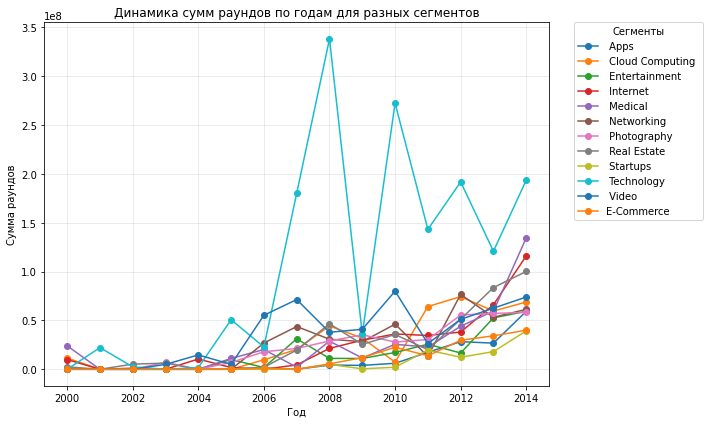

In [69]:
#Отберем только массовую категорию сегментов и визуализируем временную зависимость
for segment in growing_segments:
    if segment not in ['mid', 'niche', 'Неизвестно']:
        ax = pivot_funding[segment].plot(kind='line', figsize=(10, 6), marker='o', legend=True)
        
plt.xlabel('Год')
plt.ylabel('Сумма раундов')
plt.title('Динамика сумм раундов по годам для разных сегментов')
plt.grid(True, alpha=0.3)
plt.legend(title='Сегменты', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()

Для большинства представленных сегментов характерен стабильный рост после 2009 года, который заметно ускоряется к 2014 году. Исключением является абсолютный лидер по объемам привлеченных средств — сегмент Technology. Его динамика отличается высокой волатильностью финансирования в 2009 и 2011 годах, которые превышают максимальные показатели всех остальных рынков.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Наша цель — для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, нужно заменить на пропуски.

In [70]:
# Создадим для данной задачи пустой датафрейм
df_return = pd.DataFrame()
#Заполним датафрейм суммами финансирования различных видов
for column in ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
               'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']:
        df_return[column] = df_investments.groupby(df_investments['mid_funding_at'].dt.year)[column].sum()
df_return

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
mid_funding_at,,,,,,,,,,,,,
2000,1.675914e+07,3.209622e+08,0.0,126202640.0,0.0,1.400000e+07,26086333.0,293114.0,0.000000e+00,3467747.0,0.0,7718867.0,0.0
2001,2.667675e+06,2.175191e+08,0.0,36596784.0,1500000.0,5.829217e+06,1000000.0,100000.0,0.000000e+00,0.0,0.0,0.0,0.0
2002,1.046519e+07,3.069406e+08,0.0,23437932.0,0.0,1.530967e+07,3000000.0,0.0,7.500000e+06,300000.0,0.0,0.0,0.0
2003,1.531836e+07,4.101844e+08,0.0,10280000.0,0.0,1.050000e+06,5629661.0,16850717.0,0.000000e+00,0.0,0.0,0.0,0.0
2004,1.797973e+07,6.026505e+08,0.0,62912359.0,0.0,2.381662e+07,11013741.0,10363600.0,0.000000e+00,0.0,0.0,0.0,0.0
2005,3.942520e+07,4.770861e+09,0.0,8871332.0,0.0,1.117207e+08,60914621.0,6266481.0,5.000000e+06,4796022.0,0.0,0.0,0.0
2006,7.564683e+07,8.978452e+09,933057.0,61545498.0,10702385.0,1.348484e+08,70956153.0,6147500.0,1.782024e+07,0.0,0.0,0.0,0.0
2007,1.907936e+08,1.188292e+10,0.0,109649902.0,14116788.0,2.054385e+08,203152441.0,33993300.0,1.449831e+08,12000000.0,0.0,0.0,0.0
2008,3.031030e+08,1.419043e+10,0.0,115776811.0,28750902.0,3.985745e+08,244299613.0,23485347.0,1.917563e+08,36000000.0,0.0,0.0,1000000.0


Вычислим доли возвращённых средств, а затем отфильтруем аномальные значения:

In [71]:
#Вычисляем доли возвращённых средств
df_res = df_return / (df_returns * 1000000 + 1e-60)
df_res = df_res.where(df_res <= 1e+60, np.nan)
df_res

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
mid_funding_at,,,,,,,,,,,,,
2000,1.003541,5.793541,0.000000,1.613638,0.000000,1.616628,4.056972,NaN,0.000000,3.689093,0.000000,38.594335,0.000000
2001,0.926276,9.260073,0.000000,1.702176,150.000000,1.298267,0.847458,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
2002,1.588041,1.465670,0.000000,0.909505,0.000000,4.476512,0.879765,0.0,4.966887,0.882353,0.000000,0.000000,0.000000
2003,1.979116,1.753974,0.000000,1.093617,0.000000,0.963303,1.650927,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
2004,1.810647,1.084099,0.000000,1.895522,0.000000,1.757684,1.199754,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
2005,1.482150,1.814761,0.000000,0.932842,0.000000,3.183832,1.961192,NaN,2.083333,1.366388,0.000000,0.000000,0.000000
2006,1.223861,2.896107,4.910826,1.316763,6.012576,1.191135,1.485993,NaN,1.069001,0.000000,0.000000,0.000000,0.000000
2007,2.709752,3.314279,0.000000,1.980312,4.384096,1.634615,1.234894,NaN,1.632509,0.492611,0.000000,0.000000,0.000000
2008,3.378322,5.222794,0.000000,2.822448,16.813393,1.002602,2.375762,NaN,1.470750,0.427148,0.000000,0.000000,NaN


С первого взгляда, к 2014 году на рынке инвестиций наметился прогресс в сторону альтернативных высокорисковых механизмов (краудфандинг, конвертируемые займы), которые начали демонстрировать многократно большую относительную отдачу по сравнению с традиционным венчурным финансированием и инвестированием на поздних стадиях.

Построим график, на котором отобразим нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

Сделаем вывод о том, в каких типах финансирования наблюдается наиболее устойчивый рост показателя.

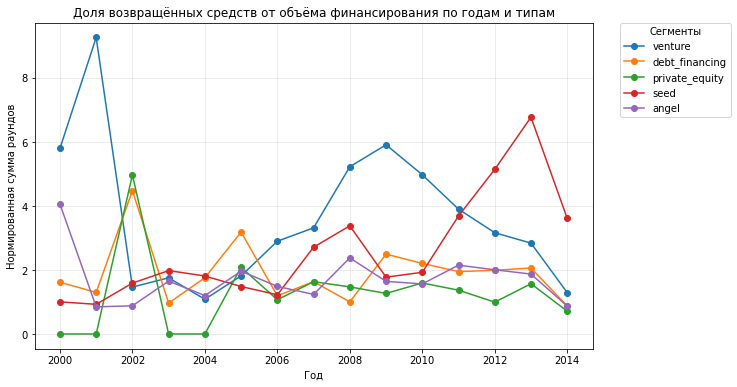

In [72]:
#Построим визуализацию для указанных типов финансирования
for returning in ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']:
    ax = df_res[returning].plot(kind='line', figsize=(10, 6), marker='o')
plt.xlabel('Год')
plt.ylabel('Нормированная сумма раундов')
plt.title('Доля возвращённых средств от объёма финансирования по годам и типам')
plt.legend(title='Сегменты', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, alpha=0.3)

До 2009 года наибольшую отдачу приносили венчурные инвестиции (venture), но затем их доходность пошла на спад. На смену им пришли посевные инвестиции (seed) - они показали резкий рост и к 2013 году стали абсолютным лидером, тогда как показатели остальных сегментов оставались стабильно низкими, но все еще окупали инвестиции в большинстве лет.


## Шаг 5. Итоговый вывод и рекомендации

### Подведём итоги
В ходе исследования проанализировали исторические данные о стартапах и инвестиционных раундах (итоговая выборка после очистки составила более 35 600 записей). Исследование охватило период до конца 2014 года. Акцент был сделан на поиске наиболее перспективных направлений для входа на рынок в 2015 году. В анализе учитывались: типы и объёмы финансирования, сегментация рынка по массовости, динамика роста отраслей и наличие аномальных «выбросов» в инвестициях.

#### Общий профиль инвестиционного рынка
Исследовательский анализ данных позволил сформировать текущий профиль рынка стартапов:

Распределение по сегментам: Рынок четко разделен на 54 массовых сегмента (где сосредоточено около 30 000 компаний) и более 700 нишевых направлений. Лидером по количеству компаний является сегмент Software, за ним следуют Biotechnology и Mobile.

Характер финансирования: 59% компаний получают финансирование единоразово. Типичный общий объем финансирования для одной компании составляет около 2 млн долларов, при этом основная масса сделок проходит в нормальном диапазоне от 350 тыс. до 10 млн долларов.

Доминирующие инструменты: Венчурное финансирование (Venture) является абсолютным лидером по суммарному объёму вложений и возвратов, значительно опережая долговые инструменты и частные инвестиции.

Факторы и тренды, определяющие динамику рынка
На инвестиционную привлекательность сегментов в 2014 году повлияли несколько ключевых факторов: темпы прироста капитала, устойчивость типа раунда и наличие аномальных сделок.

#### Ключевые наблюдения:

Абсолютными лидерами по темпам роста капитала стали направления Medical (+126,0%), Apps (+121,7%) и Startups (+117,8%), увеличившие объемы финансирования более чем в два раза по сравнению с 2013 годом.

Несмотря на общие объемы венчура, его относительная доходность падает с 2009 года. Самый стабильный восходящий тренд по доле возврата средств сейчас демонстрирует посевное финансирование (Seed), ставшее лидером эффективности к 2013-2014 годам.

Сегмент Real Estate имеет самую высокую долю «выбросов» (18% компаний), что указывает на то, что рынок в этой нише формируется немногими игроками со сверхвысокими бюджетами. В свою очередь, сегмент Technology лидирует по абсолютным объемам, но демонстрирует сильную волатильность по годам.

#### Рекомендации
В 2015 году заказчику рекомендуется сфокусировать внимание на высокотехнологичных и прикладных отраслях: Medical, Apps, Startups и Internet. Эти направления демонстрируют реальный кратный рост объёмов финансирования и высокую рыночную активность без чрезмерной волатильности гигантов.

В качестве стратегии входа наиболее уместным будет использование посевного финансирования - Seed. В последние годы этот инструмент показал наибольшую относительную отдачу инвестированных средств. Это позволит зайти в перспективные проекты на этапе их устойчивого роста с меньшими рисками, чем при работе с падающими по доходности венчурными стадиями.

### Подведём итоги
В ходе исследования проанализировали исторические данные о стартапах и инвестиционных раундах. Исследование охватило период до конца 2014 года. Акцент был сделан на поиске наиболее перспективных направлений для входа на рынок в 2015 году. В анализе учитывались: типы и объёмы финансирования, сегментация рынка по массовости, динамика роста отраслей и наличие аномальных «выбросов» в инвестициях.